In [29]:
import pandas as pd
import requests
import io

def get_wb_data(indicator, country, start_year, end_year):
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}?date={start_year}:{end_year}&format=json"
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

usa_pop = get_wb_data('SP.POP.TOTL', 'USA', 2020, 2022)
can_pop = get_wb_data('SP.POP.TOTL', 'CAN', 2020, 2022)
usa_gdp = get_wb_data('NY.GDP.PCAP.CD', 'USA', 2020, 2022)

  countryiso3code  date      value
0             USA  2022  334017321
1             USA  2021  332099760
2             USA  2020  331577720   countryiso3code  date     value
0             CAN  2022  38935934
1             CAN  2021  38239864
2             CAN  2020  38028638   countryiso3code  date         value
0             USA  2022  76657.248884
1             USA  2021  70205.050916
2             USA  2020  63515.949181


In [24]:
import pandas as pd
import requests
country = 'USA'; indicator = 'SP.POP.TOTL'; start_year = 2020; end_year = 2022
url = f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}?date={start_year}:{end_year}&format=json"
response = requests.get(url)
# response.json()
data = response.json()[1] # The first element of .json() is meta-data about pages in response, etc. From the second element are concrete data.
pd.json_normalize(data) # Transform semi-structured JSON data, such as nested dictionaries or lists, into a flat table.

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,USA,2022,334017321,,,0,SP.POP.TOTL,"Population, total",US,United States
1,USA,2021,332099760,,,0,SP.POP.TOTL,"Population, total",US,United States
2,USA,2020,331577720,,,0,SP.POP.TOTL,"Population, total",US,United States


In [39]:
combined_row = pd.concat([usa_pop, can_pop], axis = 0)
combined_row

,countryiso3code,date,value
0,USA,2022,334017321
1,USA,2021,332099760
2,USA,2020,331577720
0,CAN,2022,38935934
1,CAN,2021,38239864
2,CAN,2020,38028638


In [44]:
usa_pop_renamed = usa_pop.rename({'value': 'population'}, axis = 1)
usa_gdp_renamed = usa_gdp.rename({'value': 'gdp_per_capita'}, axis = 1)
pd.concat([usa_pop_renamed, usa_gdp_renamed], axis = 1)

,countryiso3code,date,population,countryiso3code,date,gdp_per_capita
0,USA,2022,334017321,USA,2022,76657.248884
1,USA,2021,332099760,USA,2021,70205.050916
2,USA,2020,331577720,USA,2020,63515.949181


In [47]:
merged_usa = pd.merge(usa_pop_renamed, usa_gdp_renamed, on=['countryiso3code','date'])
merged_usa

,countryiso3code,date,population,gdp_per_capita
0,USA,2022,334017321,76657.248884
1,USA,2021,332099760,70205.050916
2,USA,2020,331577720,63515.949181


In [52]:
df_macro_raw = pd.read_stata('https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta')
df_macro_raw.head(3)

,ISO3,year,ADB_infl,AHSTAT_infl,AMF_infl,BCEAO_infl,BIS_infl,BORDO_infl,CEPAC_infl,EUS_infl,...,OECD_KEI_infl,WB_CC_infl,WDI_infl,WDI_ARC_infl,CS1_infl,CS2_infl,infl,chainlinking_ratio,source,source_change
0,ZWE,2029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.131044,1.0,IMF_WEO,NaN
1,ZWE,2028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.108963,1.0,IMF_WEO,NaN
2,ZWE,2027.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.759129,1.0,IMF_WEO,NaN


In [64]:
response = requests.get("https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/.Q.......?startPeriod=1990-Q4&format=csv")
response.raise_for_status()
# pd.read_csv(response.text) # File not found error
data = io.StringIO(response.text)
df_oecd_raw = pd.read_csv(data)
del data; del response
df_oecd_raw

,DATAFLOW,REF_AREA,FREQ,MEASURE,ACTIVITY,UNIT_MEASURE,PRICE_BASE,TRANSFORMATION,ADJUSTMENT,CONVERSION_TYPE,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MULT,BASE_PER,DECIMALS
0,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1993-Q2,1.805471,A,0,NaN,2
1,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1993-Q3,1.243324,A,0,NaN,2
2,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1993-Q4,0.759766,A,0,NaN,2
3,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1994-Q1,1.832932,A,0,NaN,2
4,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1994-Q2,1.131933,A,0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53906,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),DEU,Q,ULCE,_T,IX,V,_Z,S,NC,2024-Q4,136.281100,A,0,2015.0,0
53907,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),DEU,Q,ULCE,_T,IX,V,_Z,S,NC,2025-Q1,137.418400,A,0,2015.0,0
53908,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),DEU,Q,ULCE,_T,IX,V,_Z,S,NC,2025-Q2,139.506900,A,0,2015.0,0
53909,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),DEU,Q,ULCE,_T,IX,V,_Z,S,NC,2025-Q3,141.448500,A,0,2015.0,0


In [117]:
df = df_macro_raw.copy()
df_nz = df[df.ISO3 == 'NZL'][['ISO3','year','OECD_KEI_infl','BIS_infl']].dropna()
df_macro_nz = df_nz.rename({'ISO3': 'country', 'year': 'date'}, axis = 1)
df_macro_nz

,country,date,OECD_KEI_infl,BIS_infl
6225,NZL,2023.0,5.733163,5.733163
6226,NZL,2022.0,7.172225,7.172225
6227,NZL,2021.0,3.941121,3.941121
6228,NZL,2020.0,1.714562,1.714562
6229,NZL,2019.0,1.619632,1.619632
...,...,...,...,...
6328,NZL,1920.0,13.653970,13.654377
6329,NZL,1919.0,115.138890,7.570689
6330,NZL,1918.0,12.324490,12.321959
6331,NZL,1917.0,9.760275,9.759180


In [96]:
df = df_oecd_raw.copy()
# df = df.query("REF_AREA == 'NZL' & MEASURE == 'ULCE' & UNIT_MEASURE == 'PA'")
# IMPORTANT: When filtering through square bracket, individual condition MUST be included in a parenthesis.
df_nz = df[(df.REF_AREA=='NZL') & (df.MEASURE=='ULCE') & (df.UNIT_MEASURE=='PA')]
cols = ['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE', 'MEASURE', 'UNIT_MEASURE']
df_oecd_nz = df_nz[cols].drop(['MEASURE','UNIT_MEASURE'], axis=1).rename({"REF_AREA":"country", "TIME_PERIOD":"date", "OBS_VALUE":"ULCE"}, axis=1)
df_oecd_nz

,country,date,ULCE
19946,NZL,2002-Q1,2.050048
19973,NZL,2012-Q3,2.678595
19984,NZL,2015-Q4,0.433704
23174,NZL,1990-Q4,1.720550
23175,NZL,1991-Q1,6.212259
...,...,...,...
23305,NZL,2024-Q2,4.872601
23306,NZL,2024-Q3,2.950099
23307,NZL,2024-Q4,4.732540
23308,NZL,2025-Q1,2.660290


In [97]:
df_oecd_nz.info()

<class 'pandas.DataFrame'>
Index: 139 entries, 19946 to 23309
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  139 non-null    str    
 1   date     139 non-null    str    
 2   ULCE     139 non-null    float64
dtypes: float64(1), str(2)
memory usage: 4.3 KB


In [124]:
df_oecd = df_oecd_nz.copy()

# .PeriodIndex: Immutable ndarray holding ordinal values indicating regular periods in time.
# .to_timestamp: Casts PeriodIndex to DatetimeIndex of timestamps, at beginning of period.
df_oecd['date'] = pd.PeriodIndex(df_oecd['date'], freq='Q').to_timestamp() 
#df_oecd['date'] = pd.to_datetime(df_oecd['date'])

# The following two methods seem equivalent:
#pd.PeriodIndex(df_oecd['date'], freq='Q').to_timestamp() 
#pd.to_datetime(df_oecd['date'])

df_oecd_nz_dt = df_oecd
df_oecd_nz_dt

,country,date,ULCE
19946,NZL,2002-01-01,2.050048
19973,NZL,2012-07-01,2.678595
19984,NZL,2015-10-01,0.433704
23174,NZL,1990-10-01,1.720550
23175,NZL,1991-01-01,6.212259
...,...,...,...
23305,NZL,2024-04-01,4.872601
23306,NZL,2024-07-01,2.950099
23307,NZL,2024-10-01,4.732540
23308,NZL,2025-01-01,2.660290


In [127]:
df_macro = df_macro_nz.copy()
df_macro['date'] = pd.to_datetime(df_macro_nz['date'], format = "%Y") # Parameter format is a must, or to_datetime cannot comprehend what the original "2023.0" means.

df_macro_nz_dt = df_macro
df_macro_nz_dt

,country,date,OECD_KEI_infl,BIS_infl
6225,NZL,2023-01-01,5.733163,5.733163
6226,NZL,2022-01-01,7.172225,7.172225
6227,NZL,2021-01-01,3.941121,3.941121
6228,NZL,2020-01-01,1.714562,1.714562
6229,NZL,2019-01-01,1.619632,1.619632
...,...,...,...,...
6328,NZL,1920-01-01,13.653970,13.654377
6329,NZL,1919-01-01,115.138890,7.570689
6330,NZL,1918-01-01,12.324490,12.321959
6331,NZL,1917-01-01,9.760275,9.759180


In [151]:
df_macro_indexed = df_macro_nz_dt.set_index(['country','date'])
df_macro_indexed
df_oecd_indexed = df_oecd_nz_dt.set_index(['country','date'])
df_oecd_indexed

ULCE
country date                
NZL     2002-01-01  2.050048
        2012-07-01  2.678595
        2015-10-01  0.433704
        1990-10-01  1.720550
        1991-01-01  6.212259
...                      ...
        2024-04-01  4.872601
        2024-07-01  2.950099
        2024-10-01  4.732540
        2025-01-01  2.660290
        2025-04-01  3.334858

[139 rows x 1 columns]

In [155]:
df_merged = pd.merge(df_macro_indexed, df_oecd_indexed, 
                     right_index=True, left_index=True, how='inner')
df_merged.head(5)

# Alternative way (without merging by index)
#pd.merge(df_macro_nz_dt, df_oecd_nz_dt, on=['country','date'], how='outer')

OECD_KEI_infl  BIS_infl       ULCE
country date                                          
NZL     2023-01-01       5.733163  5.733163   5.275818
        2022-01-01       7.172225  7.172225  10.219310
        2021-01-01       3.941121  3.941121   0.635275
        2020-01-01       1.714562  1.714562   5.094663
        2019-01-01       1.619632  1.619632   1.716384

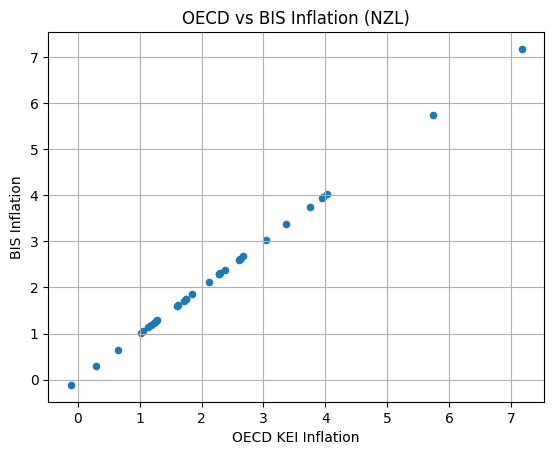

In [174]:
import matplotlib.pyplot as plt
#plt.scatter(df_merged.OECD_KEI_infl, df_merged.BIS_infl)
df_merged.plot(x='OECD_KEI_infl', y='BIS_infl', kind='scatter')
plt.xlabel("OECD KEI Inflation")
plt.ylabel("BIS Inflation")
plt.title('OECD vs BIS Inflation (NZL)')
plt.grid(True)